# 📊 Stock Market Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
stock = yf.download("RELIANCE.NS", start="2021-01-01", end="2026-05-06")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-01-01,901.194641,905.502206,898.700750,901.421320,10015175
2021-01-04,902.713623,906.363699,892.352703,904.640696,24513534
2021-01-05,891.491150,899.426182,886.911450,892.806069,24123091
2021-01-06,867.980774,891.445793,863.854552,891.400457,46401468
2021-01-07,866.575195,881.923840,863.854624,870.814757,32325918


In [3]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-04-29,1425.400024,1433.800049,1391.300049,1392.000000,30542143
2026-04-30,1430.800049,1437.000000,1393.099976,1409.000000,30957881
2026-05-01,1430.800049,1430.800049,1430.800049,1430.800049,0
2026-05-04,1463.099976,1467.400024,1433.400024,1433.400024,24035700
2026-05-05,1463.599976,1473.400024,1450.000000,1460.000000,23543341


In [4]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1319 entries, 2021-01-01 to 2026-05-05
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1319 non-null   float64
 1   (High, RELIANCE.NS)    1319 non-null   float64
 2   (Low, RELIANCE.NS)     1319 non-null   float64
 3   (Open, RELIANCE.NS)    1319 non-null   float64
 4   (Volume, RELIANCE.NS)  1319 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 61.8 KB


In [5]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1319.000000,1319.000000,1319.000000,1319.000000,1.319000e+03
mean,1232.444935,1244.189064,1221.356131,1232.906712,1.412666e+07
std,180.251751,180.948216,179.522545,180.125087,7.978888e+06
min,835.197693,863.786543,829.779159,843.110097,0.000000e+00
25%,1106.100098,1118.418069,1097.489063,1107.977027,9.071738e+06
50%,1209.919922,1218.846089,1199.673038,1210.166735,1.208245e+07
75%,1398.900024,1413.094846,1386.698131,1398.170103,1.686722e+07
max,1592.300049,1611.800049,1578.199951,1593.000000,9.146198e+07


In [6]:
stock.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

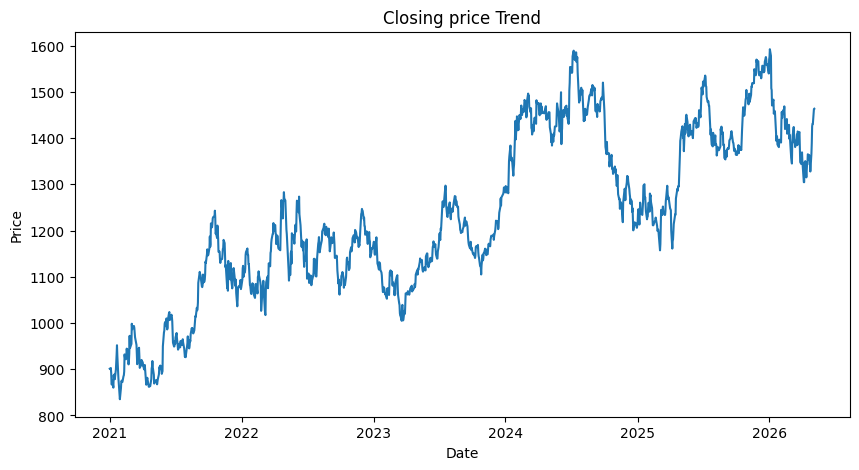

In [7]:
#visualization

plt.figure(figsize=(10,5))
plt.title("Closing price Trend")
plt.plot(stock['Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

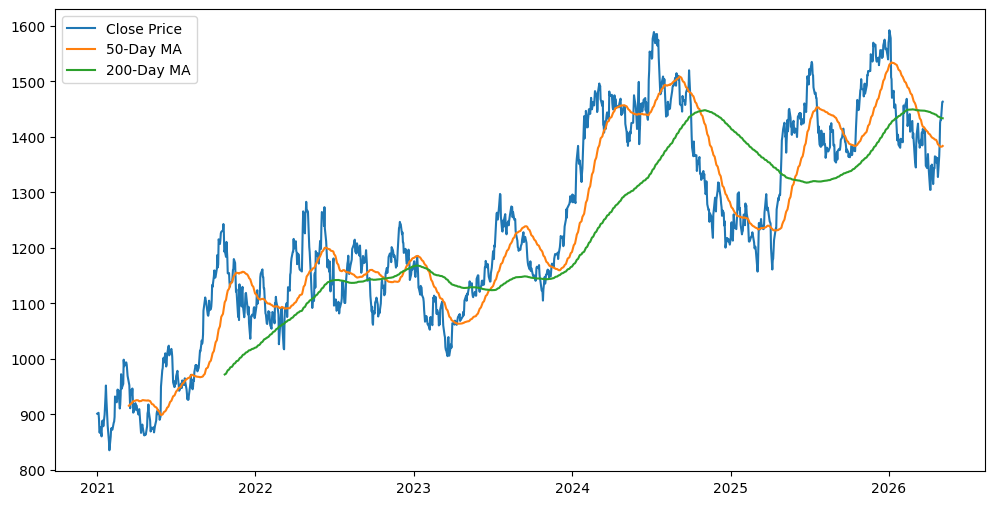

In [8]:
#Moving Averages
stock['MA50'] = stock['Close'].rolling(window=50).mean()
stock['MA200'] = stock['Close'].rolling(window=200).mean()

plt.figure(figsize=(12,6))
plt.plot(stock['Close'], label='Close Price')
plt.plot(stock['MA50'], label='50-Day MA')
plt.plot(stock['MA200'], label='200-Day MA')
plt.legend()
plt.show()

In [47]:
Look at blue (price)
Then orange (short trend)
Then green (long trend)
Then crossovers

🔹 When Blue is ABOVE both lines
👉 Stock is strong/bullish

🔹 When Blue is BELOW both lines
👉 Stock is weak/bearish

🟢 Golden Cross (BUY SIGNAL)
👉 When: Orange (MA50) goes above Green (MA200)-
The short-term trend becomes stronger than the long-term trend
Possible price increase
Indicates the start of an upward trend
Good potential entry point

🔴 Death Cross (SELL SIGNAL)
👉 When: Orange (MA50) goes below Green (MA200)-
Short-term trend weakens
Possible price drop
Indicates weakness / downward trend
Possible exit point

SyntaxError: invalid character '🔹' (U+1F539) (1752854251.py, line 6)

<Axes: xlabel='Daily Return', ylabel='Count'>

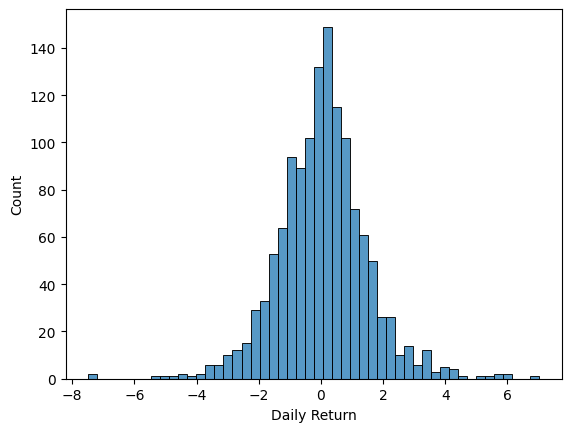

In [9]:
#Daily Returns Analysis explain

stock['Daily Return'] = stock['Close'].pct_change()*100

sns.histplot(stock['Daily Return'].dropna(), bins= 50)

In [ ]:
It measures how much the stock price changes each day (in %).
X-axis → Return values (e.g., -3% to +3%)
Y-axis → Frequency (how often it happens)
👉 Instead of looking at price (₹1000 → ₹1020),
we look at percentage change (2%).

📊 Why Do We Analyze Daily Returns?
1. Measure Volatility (Risk)
Large ups & downs → 🔥 High risk
Small changes → 🧊 Stable stock
2. Understand Behavior
Mostly positive → 📈 Growth stock
Mixed/random → ⚖️ Uncertain
3. Compare Stocks
Which stock is more stable?
Which gives better returns?

🧠 How to Interpret That Graph
✔ If graph is centered near 0 - Most days → small changes (normal)
✔ If graph is wide (spread out) - High volatility (risky stock)
✔ If skewed to positive side - More gains than losses
✔ If skewed to negative side - More losses

Conclusion:-
On most days, stock price changed only a little.
This is normal market behavior.
Bell-Shaped Distribution - the chart roughly looks like a bell curve.
👉 This means: - Extreme gains/losses are rare, Moderate movements are common
You can see small bars far away:- Sometimes the stock had very large movements.
Volatility Exists - chart shows: Moderate volatility, Some extreme movements
Slight Positive Bias - There are slightly more bars on the positive side. 
    Overall upward trend over long period

[*********************100%***********************]  3 of 3 completed


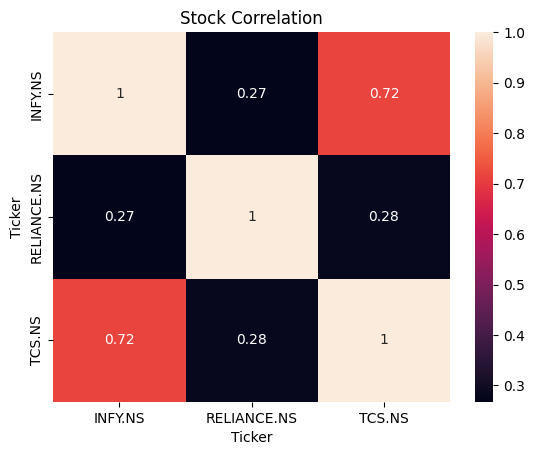

In [10]:
stocks = yf.download(["TCS.NS","INFY.NS","RELIANCE.NS"], start="2021-01-01")['Close']

stocks_returns = stocks.pct_change()

sns.heatmap(stocks_returns.corr(), annot=True)
plt.title("Stock Correlation")
plt.show()

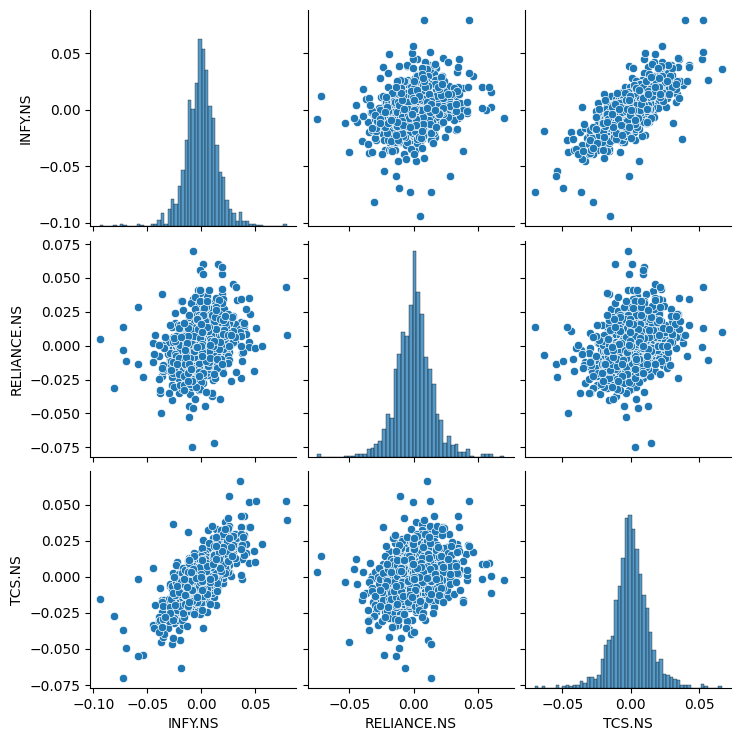

In [11]:
sns.pairplot(stocks_returns.dropna())

In [ ]:
#conclusion
1. INFY ↔ TCS = 0.72
-Infosys and TCS move most of the time similarly. Strong positive correlation
2. INFY ↔ RELIANCE = 0.27
-Very weak relationship. They do NOT strongly move together.
3. RELIANCE ↔ TCS = 0.28
-Weak positive correlation. Sometimes move similarly. Mostly independent behavior